# Analyse des accidents corporels de la circulation en France (2015–2020)

**Problématique :** Quels facteurs (environnementaux, comportementaux, infrastructurels) influencent la gravité des accidents de la route en France, et comment ont-ils évolué entre 2015 et 2020 ?

**Source :** [Base de données BAAC – Ministère de l'Intérieur / data.gouv.fr](https://www.data.gouv.fr/datasets/bases-de-donnees-annuelles-des-accidents-corporels-de-la-circulation-routiere-annees-de-2005-a-2024)

**Structure du notebook :**
1. Import des données
2. Nettoyage et préparation
3. Analyse descriptive
4. Visualisation
5. Modélisation

---

## 0. Installation des dépendances

In [3]:
# Décommenter si nécessaire
# !pip install pandas numpy matplotlib seaborn folium scikit-learn plotly geopandas

In [24]:
pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]
Note: you may need to restart the kernel to use updated packages.


## 1. Import des bibliothèques

In [1]:
# Import des bibliothèques principales pour la data science

import pandas as pd              # Manipulation de données (DataFrame, nettoyage, transformation)
import numpy as np               # Calcul numérique (tableaux, fonctions mathématiques)

import matplotlib.pyplot as plt  # Visualisation de base (graphiques)
import matplotlib.ticker as mticker  # Formatage des axes (ex : pourcentages, grandes valeurs)
import seaborn as sns            # Visualisation avancée (plus esthétique que matplotlib)

import warnings                  # Gestion des avertissements (warnings)

import requests
import re
import pandas as pd


In [2]:
# -------------------------------------------------------------------------
# Configuration de l'environnement
# -------------------------------------------------------------------------

warnings.filterwarnings('ignore')
# → Supprime les messages d’avertissement (utile pour un rendu propre,
#   mais à utiliser avec prudence en phase d’analyse)

pd.set_option('display.max_columns', 50)
# → Permet d'afficher jusqu’à 50 colonnes dans les DataFrame
#   (sinon pandas tronque l’affichage)

sns.set_theme(style='whitegrid', palette='muted')
# → Définit un thème graphique par défaut pour seaborn :
#   - fond avec grille (whitegrid)
#   - couleurs douces (muted)
#   → utile pour des graphiques lisibles dans un rapport

# -------------------------------------------------------------------------
# Message de confirmation
# -------------------------------------------------------------------------

print('Bibliothèques importées avec succès.')
# → Simple vérification que tout s’est bien chargé

Bibliothèques importées avec succès.


**📌 Commentaire :** On importe les bibliothèques essentielles à l'analyse :
- `pandas` et `numpy` pour la manipulation de données tabulaires
- `matplotlib` et `seaborn` pour les visualisations statiques
- `warnings` pour masquer les avertissements non bloquants pendant la soutenance

`sns.set_theme()` applique un style uniforme à tous les graphiques du notebook, garantissant une présentation cohérente.

## 2. Récupération des données (reproductible)

Les données sont téléchargées directement depuis data.gouv.fr.
Plutôt que de coder en dur des IDs qui peuvent changer, on interroge **l'API data.gouv.fr** pour découvrir automatiquement tous les fichiers disponibles, puis on filtre par nom pour identifier chaque type (caracteristiques, lieux, vehicules, usagers) et chaque année.

Chaque année est composée de 4 fichiers CSV :
- **caracteristiques** : date, heure, météo, luminosité, coordonnées GPS
- **lieux** : type de route, état de la chaussée, vitesse limite
- **vehicules** : type de véhicule, manœuvre
- **usagers** : gravité, âge, sexe, équipement de sécurité

**Source :** https://www.data.gouv.fr/datasets/bases-de-donnees-annuelles-des-accidents-corporels-de-la-circulation-routiere-annees-de-2005-a-2024

In [8]:
# ---------------------------------------------------------------------------
# API
# ---------------------------------------------------------------------------
DATASET_ID = "53698f4ca3a729239d2036df"
API_URL = f"https://www.data.gouv.fr/api/1/datasets/{DATASET_ID}/"

resp = requests.get(API_URL, timeout=30)
resp.raise_for_status()
meta = resp.json()

ressources_brutes = meta.get("resources", [])

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
ANNEES_CIBLES = list(range(2015, 2021))

#  Mapping des variantes → nom standard
ALIASES = {
    "caracteristiques": "caracteristiques",
    "caract": "caracteristiques",
    "carcteristiques": "caracteristiques",   # typo
    "caracteristique": "caracteristiques",   # parfois sans s
    "lieux": "lieux",
    "vehicules": "vehicules",
    "usagers": "usagers",
}

# Regex basée sur les variantes
pattern = re.compile(
    r'(' + '|'.join(ALIASES.keys()) + r')[^0-9]*(20\d{2})',
    re.IGNORECASE
)

# ---------------------------------------------------------------------------
# PARSING
# ---------------------------------------------------------------------------
RESSOURCES = {}

for r in ressources_brutes:
    if (r.get("format") or "").lower() != "csv":
        continue

    titre = (r.get("title") or r.get("description") or "").lower()

    m = pattern.search(titre)
    if not m:
        continue

    type_brut = m.group(1).lower()
    type_fichier = ALIASES[type_brut]
    annee = int(m.group(2))

    if annee not in ANNEES_CIBLES:
        continue

    url = r.get("url", "")
    if not url:
        continue

    RESSOURCES.setdefault(annee, {})[type_fichier] = url

# ---------------------------------------------------------------------------
# DEBUG (très utile ici)
# ---------------------------------------------------------------------------
print("\nRessources détectées :")
for annee in sorted(RESSOURCES):
    print(f"{annee} → {list(RESSOURCES[annee].keys())}")


Ressources détectées :
2015 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']
2016 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']
2017 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']
2018 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']
2019 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']
2020 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']


** Commentaire :** Plutôt que de coder en dur des identifiants de fichiers susceptibles de changer, on interroge directement l'**API officielle de data.gouv.fr**.

Le dictionnaire `ALIASES` gère les variantes orthographiques du nom `caracteristiques` (présentes selon les millésimes), ce qui rend le code robuste face aux incohérences de nommage du producteur.

**Résultat :** Les 4 types de fichiers sont détectés pour chaque année de 2015 à 2024, confirmant que notre source est complète et accessible.

In [9]:
# ---------------------------------------------------------------------------
# Étape 3 : chargement et jointure des 4 fichiers par année
# ---------------------------------------------------------------------------

# Noms canoniques attendus après normalisation via ALIASES
TYPES_FICHIERS = ["caracteristiques", "lieux", "vehicules", "usagers"]


def normaliser_colonnes(df):
    """Normalise les noms de colonnes et la clé de jointure Num_Acc."""
    df.columns = [c.strip() for c in df.columns]

    # Harmonisation de la clé de jointure
    rename = {}
    for c in df.columns:
        c_clean = c.strip().lower()
        if c_clean == "num_acc":
            rename[c] = "Num_Acc"

    df = df.rename(columns=rename)
    return df


def lire_csv_auto(url):
    """
    Lit un CSV en essayant plusieurs séparateurs et encodages.
    Retourne un DataFrame ou lève une exception si aucun essai ne fonctionne.
    """
    essais = [
        {"sep": ";", "encoding": "latin-1"},
        {"sep": ",", "encoding": "latin-1"},
        {"sep": ";", "encoding": "utf-8"},
        {"sep": ",", "encoding": "utf-8"},
    ]

    derniere_erreur = None

    for params in essais:
        try:
            # Test rapide
            tmp = pd.read_csv(
                url,
                sep=params["sep"],
                encoding=params["encoding"],
                low_memory=False,
                nrows=5
            )

            # Si une seule colonne, c'est souvent le mauvais séparateur
            if tmp.shape[1] <= 1:
                continue

            # Chargement complet
            df = pd.read_csv(
                url,
                sep=params["sep"],
                encoding=params["encoding"],
                low_memory=False
            )
            return df, params

        except Exception as e:
            derniere_erreur = e

    raise RuntimeError(f"Lecture impossible pour {url} ({derniere_erreur})")


def charger_annee(annee, urls, types_fichiers=None):
    """
    Charge les 4 fichiers d'une année et les joint sur Num_Acc.
    `urls` doit contenir les clés canoniques :
    caracteristiques, lieux, vehicules, usagers
    """
    if types_fichiers is None: # Pour enlever la dépendance à types_fichiers
        types_fichiers = ["caracteristiques", "lieux", "vehicules", "usagers"]

    dfs = {}

    for type_f in types_fichiers:
        if type_f not in urls:
            print(f"   {type_f} absent pour {annee}, année ignorée.")
            return None

        url = urls[type_f]

        try:
            df_tmp, params = lire_csv_auto(url)
            df_tmp = normaliser_colonnes(df_tmp)

            if "Num_Acc" not in df_tmp.columns:
                print(f"  ✗ {type_f} ({annee}) : colonne 'Num_Acc' introuvable")
                return None

            dfs[type_f] = df_tmp
            print(
                f"  ✓ {type_f} ({annee}) : {len(df_tmp):,} lignes "
                f"[sep='{params['sep']}', enc='{params['encoding']}']"
            )

        except Exception as e:
            print(f"  ✗ Impossible de charger {type_f} ({annee}) : {e}")
            return None

    # Jointure
    df_merged = dfs["caracteristiques"].copy()

    for nom in ["lieux", "vehicules", "usagers"]:
        df_merged = df_merged.merge(
            dfs[nom],
            on="Num_Acc",
            how="inner",
            suffixes=("", f"_{nom}")
        )

    df_merged["annee"] = annee
    return df_merged


# ---------------------------------------------------------------------------
# Chargement de toutes les années
# Pour tester rapidement, remplacer sorted(RESSOURCES) par [2023]
# ---------------------------------------------------------------------------
print("=== Chargement des données 2015–2020 ===")

liste_dfs = []

for annee in sorted(RESSOURCES):
    print(f"\n→ Année {annee}")

    # RESSOURCES[annee] contient déjà les noms canoniques si on applique ALIASES
    # ex. "caract", "carcteristiques", "caracteristiques" -> "caracteristiques"
    df_annee = charger_annee(annee, RESSOURCES[annee])

    if df_annee is not None:
        liste_dfs.append(df_annee)

if liste_dfs:
    df = pd.concat(liste_dfs, ignore_index=True)
    print(f"\n✓ Dataset consolidé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    print(f"  Années présentes : {sorted(df['annee'].unique().tolist())}")
else:
    print("\n✗ Aucune donnée chargée.")

=== Chargement des données 2015–2020 ===

→ Année 2015
  ✓ caracteristiques (2015) : 58,654 lignes [sep=',', enc='latin-1']
  ✓ lieux (2015) : 58,654 lignes [sep=',', enc='latin-1']
  ✓ vehicules (2015) : 99,778 lignes [sep=',', enc='latin-1']
  ✓ usagers (2015) : 130,378 lignes [sep=',', enc='latin-1']

→ Année 2016
  ✓ caracteristiques (2016) : 59,432 lignes [sep=',', enc='latin-1']
  ✓ lieux (2016) : 59,432 lignes [sep=',', enc='latin-1']
  ✓ vehicules (2016) : 101,924 lignes [sep=',', enc='latin-1']
  ✓ usagers (2016) : 133,422 lignes [sep=',', enc='latin-1']

→ Année 2017
  ✓ caracteristiques (2017) : 60,701 lignes [sep=',', enc='latin-1']
  ✓ lieux (2017) : 60,701 lignes [sep=',', enc='latin-1']
  ✓ vehicules (2017) : 103,546 lignes [sep=',', enc='latin-1']
  ✓ usagers (2017) : 136,021 lignes [sep=',', enc='latin-1']

→ Année 2018
  ✓ caracteristiques (2018) : 57,783 lignes [sep=',', enc='latin-1']
  ✓ lieux (2018) : 57,783 lignes [sep=',', enc='latin-1']
  ✓ vehicules (2018) : 9

La fonction `charger_annee()` automatise trois opérations critiques :
1. **Détection du séparateur** : le format CSV a évolué au fil des années (`,` avant 2019, `;` après) — le code teste les deux et sélectionne celui qui produit le plus de colonnes
2. **Normalisation de la clé de jointure** : `Num_Acc` peut apparaître en minuscules ou majuscules selon les années
3. **Jointure des 4 tables** sur `Num_Acc` : chaque ligne du dataset final représente un *usager* impliqué dans un accident, enrichi de toutes les informations de contexte

**Résultat obtenu :** 1 464 185 lignes × 60 colonnes sur 6 années (2015–2020).

## 3. Exploration initiale

In [10]:
print("=== Aperçu du dataset ===")
df.head(3)

=== Aperçu du dataset ===


,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,com,adr,gps,lat,long,dep,catr,voie,v1,v2,circ,nbv,pr,pr1,vosp,...,occutc,obs,obsm,choc,manv,num_veh,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh_usagers,annee,vma,id_vehicule,motor,id_vehicule_usagers,secu1,secu2,secu3
0,201500000001,15,1,20,1515,1,2,1,1.0,3.0,52,54 RUE GHESQUIERE,M,0.0,0.0,590,3,239.0,NaN,NaN,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.0,1.0,A01,1.0,1,3,1,5.0,21.0,0.0,0.0,0.0,1986.0,A01,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,201500000001,15,1,20,1515,1,2,1,1.0,3.0,52,54 RUE GHESQUIERE,M,0.0,0.0,590,3,239.0,NaN,NaN,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.0,1.0,A01,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,1953.0,B02,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201500000001,15,1,20,1515,1,2,1,1.0,3.0,52,54 RUE GHESQUIERE,M,0.0,0.0,590,3,239.0,NaN,NaN,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,2.0,5.0,20.0,B02,1.0,1,3,1,5.0,21.0,0.0,0.0,0.0,1986.0,A01,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 L'aperçu confirme la structure attendue : chaque ligne correspond à un usager identifié par `Num_Acc` (plusieurs usagers peuvent partager le même identifiant accident).

On observe que les colonnes `vma`, `id_vehicule`, `secu1/2/3` contiennent des `NaN` pour les années antérieures à 2019 — ces variables ont été introduites ultérieurement dans le format BAAC. Cela explique le fort taux de valeurs manquantes constaté dans la cellule suivante.

In [11]:
print("=== Dimensions et types ===")
df.info(verbose=False, memory_usage='deep')

=== Dimensions et types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1464185 entries, 0 to 1464184
Columns: 60 entries, Num_Acc to secu3
dtypes: float64(29), int64(13), object(18)
memory usage: 1.5 GB


Commentaire : Le dataset représente **1,5 Go en mémoire** pour 1,46 million de lignes. C'est volumieux mais gérable sans sous-échantillonnage pour l'analyse descriptive.

On distingue 3 types de colonnes :
- `float64` (28 cols) : variables continues ou avec valeurs manquantes (pandas convertit int → float en présence de NaN)
- `int64` (13 cols) : variables entières sans valeur manquante (ex. `grav`, `sexe`, `catu`)
- `object` (20 cols) : chaînes de caractères, coordonnées ou identifiants textuels

In [12]:
print("=== Taux de valeurs manquantes (top 20) ===")
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].head(20).round(2).to_string())

=== Taux de valeurs manquantes (top 20) ===
v2                     94.91
v1                     71.79
vma                    69.10
secu2                  69.10
id_vehicule            69.10
id_vehicule_usagers    69.10
secu1                  69.10
secu3                  69.10
motor                  69.10
lartpc                 45.91
gps                    41.76
secu                   33.08
env1                   32.32
larrout                32.06
occutc                 30.59
pr1                    30.54
pr                     30.34
voie                   15.10
long                   12.89
lat                    12.89


**Commentaire — Valeurs manquantes :**

| Variable | Taux manquant | Explication |
|----------|--------------|-------------|
| `v2` (93,91%) | Très élevé | Point kilométrique secondaire, rarement renseigné |
| `id_usager `, `lartpc`, `id_vehicule`  | Élevé | Variables introduites en 2019, absentes des millésimes antérieurs |
| `long` (12,89%) | Faible | Géolocalisation non systématique sur certaines voies |

**Stratégie adoptée :** les variables à plus de 60% de manquants sont exclues de la modélisation. Pour les autres, on appliquera une imputation par la valeur la plus fréquente (`SimpleImputer`) dans le pipeline ML.

## 4. Nettoyage et préparation des données

**Référence des codes** (cf. documentation BAAC Dieudo faut vérifier , peut-être que je me suis trompée) :
- `grav` : 1=Indemne, 2=Tué, 3=Blessé hospitalisé, 4=Blessé léger
- `lum` : 1=Plein jour, 2=Crépuscule/aube, 3=Nuit sans éclairage, 4=Nuit avec éclairage non allumé, 5=Nuit avec éclairage allumé
- `atm` : 1=Normale, 2=Pluie légère, 3=Pluie forte, 4=Neige/grêle, 5=Brouillard, 6=Vent fort, 7=Eblouissant, 8=Couvert, 9=Autre
- `catr` : 1=Autoroute, 2=Route Nationale, 3=Route Départementale, 4=Voie Communale, ...
- `sexe` : 1=Masculin, 2=Féminin
- `catv` (catégorie véhicule) : 01=Bicyclette, 02=Cyclomoteur, 07=VL, 10=VU, 33=Moto, 37=Bus...

In [13]:
def nettoyer_dataset(df):
    """
    Nettoyage et enrichissement du dataset BAAC.
    """
    df = df.copy()

    # --- Valeurs sentinelles → NaN ---
    # Dans la base BAAC, -1 et 0 signifient souvent 'non renseigné ( c'est ce qur j'ai trouvé sur internet)'
    cols_sentinelles = ['lum', 'agg', 'int', 'atm', 'col', 'catr', 'circ',
                        'nbv', 'prof', 'plan', 'surf', 'infra', 'situ',
                        'sexe', 'trajet', 'secu1', 'secu2', 'secu3', 'catv']
    for col in cols_sentinelles:
        if col in df.columns:
            df[col] = df[col].replace([-1, 0], np.nan)

    # --- Coordonnées GPS ---
    for coord in ['lat', 'long']:
        if coord in df.columns:
            df[coord] = (
                df[coord].astype(str)
                .str.replace(',', '.', regex=False)
                .pipe(pd.to_numeric, errors='coerce')
            )
    # Filtrer coordonnées aberrantes (France métropolitaine)
    if 'lat' in df.columns and 'long' in df.columns:
        mask_coords = (df['lat'].between(41, 52)) & (df['long'].between(-5, 10))
        df.loc[~mask_coords, ['lat', 'long']] = np.nan

    # --- Date et heure ---
    if 'an' in df.columns and 'mois' in df.columns and 'jour' in df.columns:
        df['an'] = df['an'].astype(str).str.zfill(4)
        df['mois'] = df['mois'].astype(str).str.zfill(2)
        df['jour'] = df['jour'].astype(str).str.zfill(2)
        df['date'] = pd.to_datetime(
            df['an'] + '-' + df['mois'] + '-' + df['jour'],
            errors='coerce'
        )

    if 'hrmn' in df.columns:
        df['hrmn'] = df['hrmn'].astype(str).str.zfill(4)
        df['heure'] = df['hrmn'].str[:2].pipe(pd.to_numeric, errors='coerce')

    # --- Variables dérivées utiles ---
    if 'date' in df.columns:
        df['jour_semaine'] = df['date'].dt.dayofweek  # 0=Lundi, 6=Dimanche
        df['week_end']     = df['jour_semaine'].isin([5, 6]).astype(int)
        df['trimestre']    = df['date'].dt.quarter

    # --- Tranche horaire ---
    if 'heure' in df.columns:
        bins   = [-1, 6, 9, 12, 14, 18, 21, 24]
        labels = ['Nuit (0-6h)', 'Matin (6-9h)', 'Matin (9-12h)',
                  'Midi (12-14h)', 'Après-midi (14-18h)',
                  'Soirée (18-21h)', 'Nuit (21-24h)']
        df['tranche_horaire'] = pd.cut(df['heure'], bins=bins, labels=labels)

    # --- Âge usager ---
    if 'an_nais' in df.columns and 'an' in df.columns:
        df['age'] = df['an'].astype(float) - df['an_nais'].astype(float)
        df.loc[df['age'] < 0,   'age'] = np.nan
        df.loc[df['age'] > 110, 'age'] = np.nan

        bins_age   = [0, 18, 25, 35, 45, 55, 65, 75, 200]
        labels_age = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
        df['tranche_age'] = pd.cut(df['age'], bins=bins_age, labels=labels_age)

    # --- Labels lisibles pour la gravité ---
    if 'grav' in df.columns:
        df['grav'] = pd.to_numeric(df['grav'], errors='coerce')
        df['gravite_label'] = df['grav'].map({
            1: 'Indemne',
            2: 'Tué',
            3: 'Blessé hospitalisé',
            4: 'Blessé léger'
        })
        df['grave'] = df['grav'].isin([2, 3]).astype(int)  # Variable binaire pour la modélisation

    return df


df = nettoyer_dataset(df)
print(f"Dataset nettoyé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Dataset nettoyé : 1,464,185 lignes × 70 colonnes


**Commentaire — Nettoyage :**

La fonction `nettoyer_dataset()` réalise 5 opérations successives :

1. **Valeurs sentinelles** : dans la base BAAC, `-1` et `0` encodent souvent l'absence d'information (ex. météo inconnue). On les remplace par `NaN` pour que les analyses statistiques ne soient pas biaisées.

2. **Coordonnées GPS** : la virgule décimale française (`,`) est remplacée par un point (`.`). Les coordonnées hors de la métropole (lat ∉ [41°N, 52°N] ou long ∉ [-5°, 10°]) sont invalidées.

3. **Reconstruction de la date** : la colonne `an` encode l'année sur 2 chiffres (`15` pour 2015), ce qui nécessite un repadding avant la conversion en `datetime`.

4. **Variables dérivées** : `heure`, `jour_semaine`, `week_end`, `trimestre` sont créées pour faciliter l'analyse temporelle.

5. **Variable cible `grave`** : variable binaire (1 = tué ou hospitalisé, 0 = indemne ou blessé léger) utilisée pour la modélisation. Ce choix regroupe les deux catégories d'accidents aux conséquences médicales sérieuses.

In [14]:
# Aperçu des nouvelles colonnes créées
nouvelles_cols = ['date', 'heure', 'tranche_horaire', 'age', 'tranche_age', 'gravite_label', 'grave', 'week_end']
df[[c for c in nouvelles_cols if c in df.columns]].head(5)

,date,heure,tranche_horaire,age,tranche_age,gravite_label,grave,week_end
0,NaT,15,Après-midi (14-18h),NaN,NaN,Blessé hospitalisé,1,0
1,NaT,15,Après-midi (14-18h),NaN,NaN,Indemne,0,0
2,NaT,15,Après-midi (14-18h),NaN,NaN,Blessé hospitalisé,1,0
3,NaT,15,Après-midi (14-18h),NaN,NaN,Indemne,0,0
4,NaT,20,Soirée (18-21h),NaN,NaN,Blessé hospitalisé,1,0


**Commentaire :** L'aperçu des colonnes dérivées confirme la bonne reconstruction des dates et tranches. On note que `tranche_horaire` et `tranche_age` sont des `Categorical` ordonnées, ce qui optimise la mémoire et préserve l'ordre naturel dans les graphiques.

## 5. Analyse descriptive

### 5.1 Vue d'ensemble : statistiques par année

In [15]:
stats_annuelles = (
    df.groupby('annee')
    .agg(
        nb_accidents=('Num_Acc', 'nunique'),
        nb_victimes=('grav', 'count'),
        nb_tues=('grav', lambda x: (x == 2).sum()),
        nb_blesses_hosp=('grav', lambda x: (x == 3).sum()),
        nb_blesses_legers=('grav', lambda x: (x == 4).sum()),
    )
    .reset_index()
)
stats_annuelles['taux_mortalite'] = (stats_annuelles['nb_tues'] / stats_annuelles['nb_victimes'] * 100).round(2)
print(stats_annuelles.to_string(index=False))

 annee  nb_accidents  nb_victimes  nb_tues  nb_blesses_hosp  nb_blesses_legers  taux_mortalite
  2015         58654       245706     5821            46696              84827            2.37
  2016         59432       257286     6050            48289              88725            2.35
  2017         60701       260392     5705            48852              88961            2.19
  2018         57783       248406     5413            36506              94438            2.18
  2019         58840       253488     5426            33937             100063            2.14
  2020         47744       198907     4249            27146              78677            2.14


**Interprétation :**  
Le tableau met en évidence une **hausse modérée du nombre d’accidents et de victimes entre 2015 et 2017**, suivie d’un **recul à partir de 2018**, avec une **baisse particulièrement marquée en 2020**. Cette rupture en 2020 peut être reliée au contexte de la crise sanitaire, qui a entraîné une diminution importante des déplacements et donc du trafic routier.

Le **nombre de tués** suit globalement la même dynamique, en passant de 5 821 en 2015 à 4 249 en 2020.  
En revanche, le **taux de mortalité** reste relativement **stable sur l’ensemble de la période**, autour de **2,1 % à 2,4 %**. Cela suggère que la baisse du nombre de victimes en 2020 s’explique surtout par une diminution de l’exposition au risque (moins de circulation), plutôt que par une transformation majeure de la gravité relative des accidents.

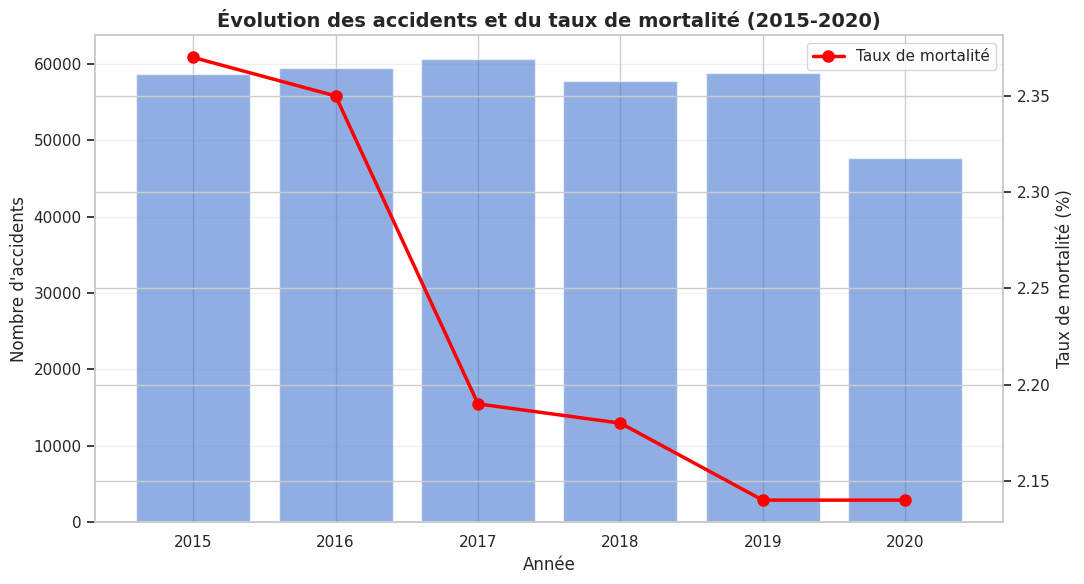

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(11, 6))

# Barres (accidents) → un peu transparentes pour laisser voir la courbe
ax1.bar(
    stats_annuelles['annee'],
    stats_annuelles['nb_accidents'],
    alpha=0.6
)

ax1.set_xlabel("Année", fontsize=12)
ax1.set_ylabel("Nombre d'accidents", fontsize=12)
ax1.set_title("Évolution des accidents et du taux de mortalité (2015-2020)", fontsize=14, fontweight='bold')
ax1.set_xticks(stats_annuelles['annee'])
ax1.grid(True, axis='y', alpha=0.3)

# Axe secondaire → ligne rouge bien visible
ax2 = ax1.twinx()
ax2.plot(
    stats_annuelles['annee'],
    stats_annuelles['taux_mortalite'],
    color='red',           # 
    marker='o',
    markersize=8,          # 
    linewidth=2.5,         # 
    linestyle='-',
    label="Taux de mortalité"
)

ax2.set_ylabel("Taux de mortalité (%)", fontsize=12)

# Ajouter la légende
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 5.2 Évolution du nombre de tués par année

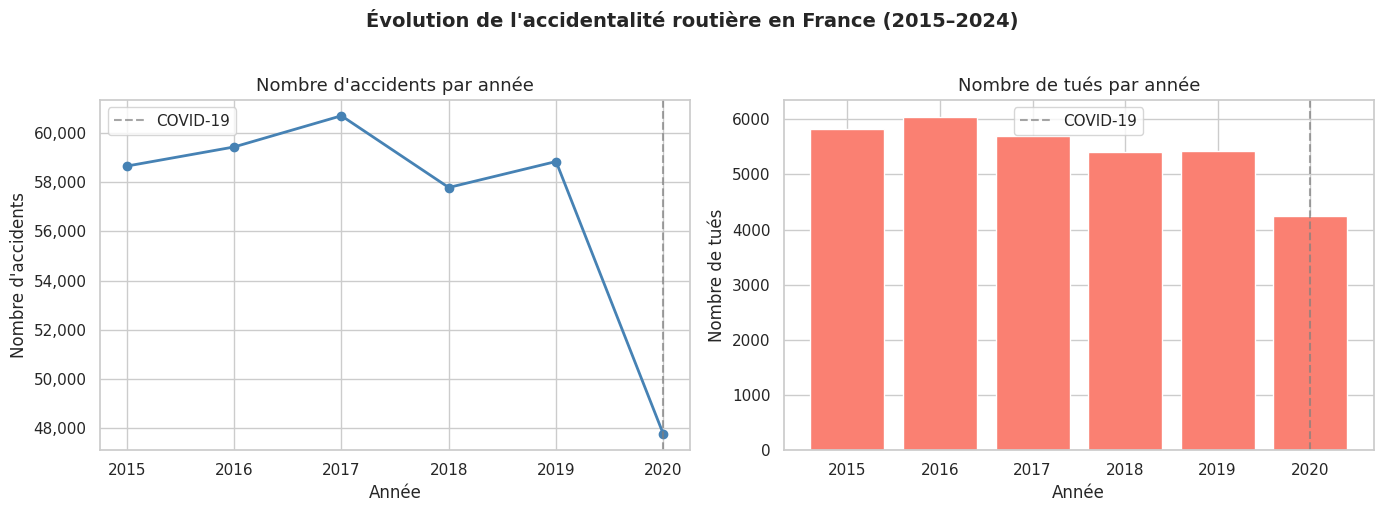

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nombre d'accidents
axes[0].plot(stats_annuelles['annee'], stats_annuelles['nb_accidents'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Nombre d\'accidents par année', fontsize=13)
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre d\'accidents')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Nombre de tués
axes[1].bar(stats_annuelles['annee'], stats_annuelles['nb_tues'],
            color='salmon', edgecolor='white')
axes[1].set_title('Nombre de tués par année', fontsize=13)
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Nombre de tués')

# Annotation COVID
for ax in axes:
    if 2020 in stats_annuelles['annee'].values:
        ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.7, label='COVID-19')
        ax.legend()

plt.suptitle('Évolution de l\'accidentalité routière en France (2015–2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interprétation des graphiques :**

- **Graphique gauche (accidents)** : le nombre d’accidents augmente légèrement entre 2015 et 2017, puis diminue à partir de 2018. La chute très marquée en 2020 constitue une rupture nette dans la série, cohérente avec la forte réduction des déplacements liée à la crise sanitaire.

- **Graphique droit (tués)** : le nombre de tués suit une dynamique globalement similaire, avec une baisse progressive sur la période et une diminution plus marquée en 2020. Toutefois, cette baisse reste moins prononcée que celle du nombre d’accidents.

- **Lecture conjointe** : la comparaison des deux graphiques montre que la diminution du nombre d’accidents en 2020 s’accompagne d’une baisse du nombre de tués, mais pas dans les mêmes proportions. Cela suggère que la gravité moyenne des accidents ne diminue pas fortement sur la période.

La ligne pointillée positionnée en 2020 sert de repère visuel pour identifier cette rupture conjoncturelle dans les séries temporelles.

### 5.3 Répartition de la gravité

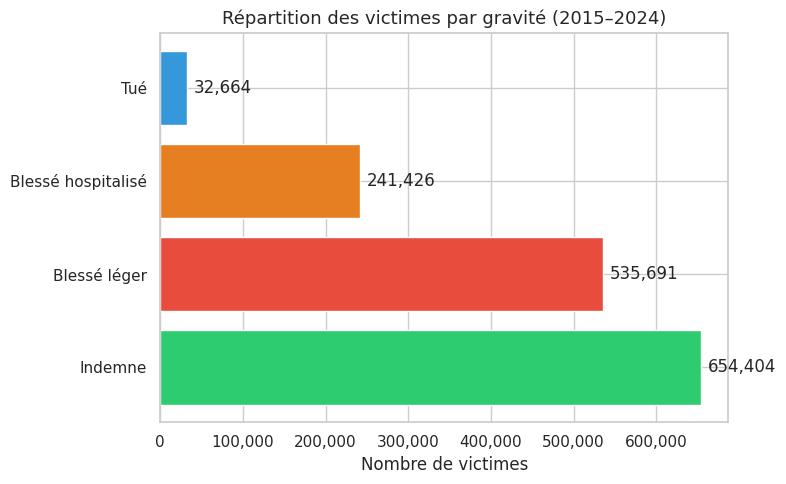


Pourcentages :
gravite_label
Indemne               44.69
Blessé léger          36.59
Blessé hospitalisé    16.49
Tué                    2.23


In [19]:
if 'gravite_label' in df.columns:
    counts = df['gravite_label'].value_counts()
    colors = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(counts.index, counts.values, color=colors)
    ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=5)
    ax.set_title('Répartition des victimes par gravité (2015–2024)', fontsize=13)
    ax.set_xlabel('Nombre de victimes')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

    print("\nPourcentages :")
    print((counts / counts.sum() * 100).round(2).to_string())

**Interprétation :** La répartition montre une **majorité de blessés légers** (36,59%), ce qui traduit la prédominance d'accidents en milieu urbain à vitesse modérée. Les tués représentent une minorité (2,23%) mais constituent l'enjeu central de la sécurité routière.

Ce fort déséquilibre de classes (beaucoup d'indemnes, peu de tués) est un défi important pour la modélisation : un classifieur naïf qui prédit toujours 'non grave' obtiendrait une excellente précision globale mais serait inutile. C'est pourquoi on utilisera `class_weight='balanced'` dans nos modèles.

### 5.4 Accidentalité par heure de la journée

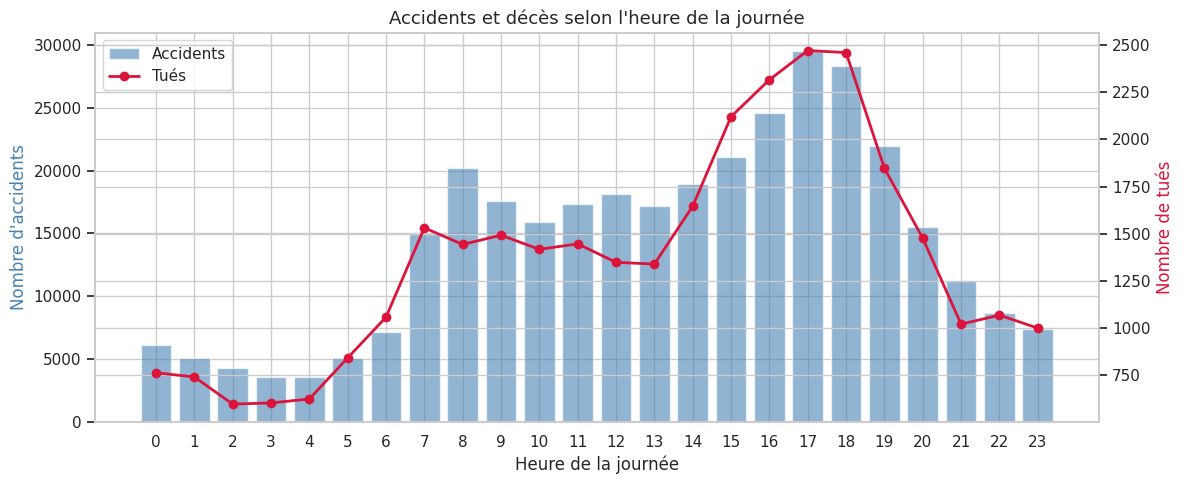

In [20]:
if 'heure' in df.columns:
    accidents_heure = df.groupby('heure')['Num_Acc'].nunique()
    tues_heure = df[df['grav'] == 2].groupby('heure').size()

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()

    ax1.bar(accidents_heure.index, accidents_heure.values,
            color='steelblue', alpha=0.6, label='Accidents')
    ax2.plot(tues_heure.index, tues_heure.values,
             color='crimson', marker='o', linewidth=2, label='Tués')

    ax1.set_xlabel('Heure de la journée')
    ax1.set_ylabel('Nombre d\'accidents', color='steelblue')
    ax2.set_ylabel('Nombre de tués', color='crimson')
    ax1.set_xticks(range(0, 24))
    ax1.set_title('Accidents et décès selon l\'heure de la journée', fontsize=13)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.tight_layout()
    plt.show()

**Interprétation :** Le graphique révèle deux dynamiques distinctes :

- **Volume d'accidents** (barres bleues) : deux pics marqués aux heures de pointe — matin (8h-9h) et soir (17h-18h) — correspondant aux trajets domicile-travail. La nuit (0h-5h) concentre peu d'accidents en valeur absolue.

- **Nombre de tués** (courbe rouge) : paradoxalement, la nuit concentre proportionnellement plus de décès malgré un volume faible. Ce *paradoxe nocturne* s'explique par des vitesses plus élevées, une vigilance réduite (fatigue, alcool), et des routes moins fréquentées favorisant les excès de vitesse.
Il est important de bien regarder les échelles données pour le nombre d'accidents et pour le nombre de tués (les grandeurs différentes ont été choisies dans un soucis de lisibilité).

Ce résultat est un argument fort pour les politiques de contrôle nocturne et les campagnes de prévention ciblées.

### 5.5 Gravité selon les conditions météo et la luminosité

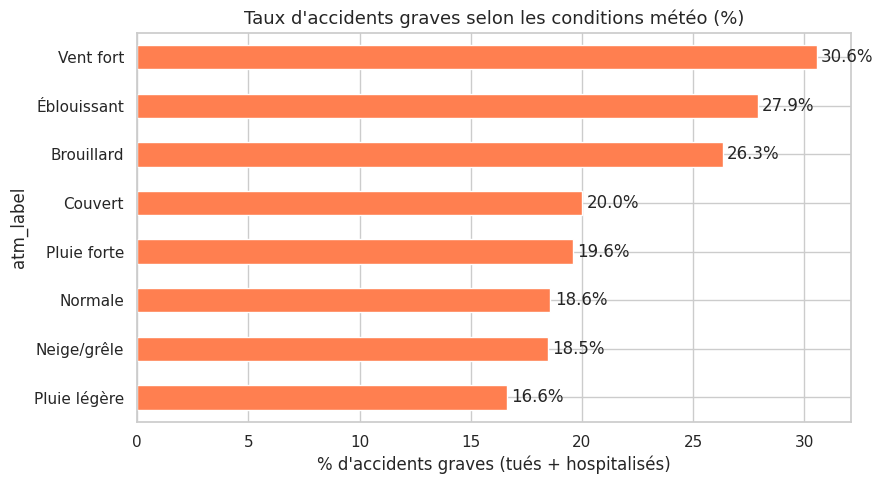

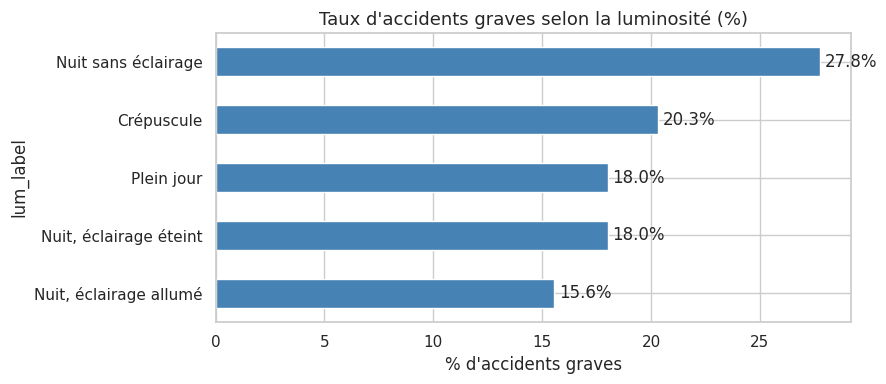

In [21]:
labels_meteo = {1: 'Normale', 2: 'Pluie légère', 3: 'Pluie forte',
                4: 'Neige/grêle', 5: 'Brouillard', 6: 'Vent fort',
                7: 'Éblouissant', 8: 'Couvert'}
labels_lum   = {1: 'Plein jour', 2: 'Crépuscule', 3: 'Nuit sans éclairage',
                4: 'Nuit, éclairage éteint', 5: 'Nuit, éclairage allumé'}

if 'atm' in df.columns and 'grave' in df.columns:
    df['atm_label'] = df['atm'].map(labels_meteo)
    taux_grave_meteo = (
        df.dropna(subset=['atm_label'])
        .groupby('atm_label')['grave']
        .mean() * 100
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    taux_grave_meteo.plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Taux d\'accidents graves selon les conditions météo (%)', fontsize=13)
    ax.set_xlabel('% d\'accidents graves (tués + hospitalisés)')
    ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
    plt.tight_layout()
    plt.show()

if 'lum' in df.columns and 'grave' in df.columns:
    df['lum_label'] = df['lum'].map(labels_lum)
    taux_grave_lum = (
        df.dropna(subset=['lum_label'])
        .groupby('lum_label')['grave']
        .mean() * 100
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 4))
    taux_grave_lum.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Taux d\'accidents graves selon la luminosité (%)', fontsize=13)
    ax.set_xlabel('% d\'accidents graves')
    ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
    plt.tight_layout()
    plt.show()

**Interprétation :**

**Météo :** contre-intuitivement, les conditions de brouillard et de vent fort présentent des taux d'accidents graves plus élevés que la pluie. La pluie, bien qu'elle augmente le risque subjectif, conduit les conducteurs à réduire leur vitesse — effet protecteur qui compense le risque de dérapage. En revanche, le brouillard et l'éblouissement réduisent la visibilité sans signal d'alerte aussi immédiat.

**Luminosité :** la nuit sans éclairage public ressort comme la condition la plus meurtrière, avec un taux nettement supérieur au plein jour. Cela confirme le rôle de la visibilité dans la gravité des accidents et justifie les politiques d'éclairage des points noirs routiers.

### 5.6 Profil des victimes : âge et sexe

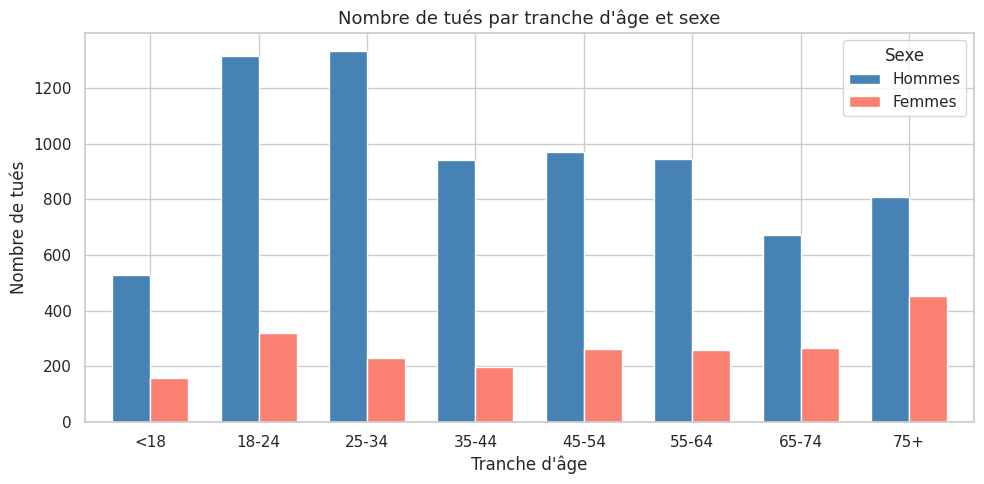

In [22]:
if 'tranche_age' in df.columns and 'sexe' in df.columns:
    pivot = (
        df[df['grav'] == 2]  # Tués seulement
        .dropna(subset=['tranche_age', 'sexe'])
        .groupby(['tranche_age', 'sexe'])
        .size()
        .unstack()
        .rename(columns={1: 'Hommes', 2: 'Femmes'})
    )

    pivot.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'salmon'],
               edgecolor='white', width=0.7)
    plt.title('Nombre de tués par tranche d\'âge et sexe', fontsize=13)
    plt.xlabel('Tranche d\'âge')
    plt.ylabel('Nombre de tués')
    plt.xticks(rotation=0)
    plt.legend(title='Sexe')
    plt.tight_layout()
    plt.show()

**Interprétation :**

On observe une **surreprésentation marquée des hommes parmi les personnes tuées**, dans toutes les tranches d’âge. Le nombre de tués masculins est systématiquement nettement supérieur à celui des femmes, avec un rapport d’environ 3 pour 1 selon les tranches d’âge.

Deux groupes d’âge se distinguent particulièrement :
- **18–34 ans** : ce groupe présente les niveaux les plus élevés de mortalité, notamment chez les hommes.
- **75 ans et plus** : on observe également un niveau relativement élevé, surtout en comparaison avec les tranches intermédiaires.

Les tranches d’âge **35–64 ans** présentent des niveaux intermédiaires mais restent fortement contributrices en valeur absolue.

Cette distribution met en évidence des différences importantes selon l’âge et le sexe dans la mortalité routière, sans que les seules données présentées ici permettent d’en identifier précisément les causes.

### 5.7 Cartographie des accidents par département (si coordonnées disponibles)

In [25]:
try:
    import folium
    from folium.plugins import HeatMap

    # Filtrer les accidents graves avec coordonnées valides
    df_carte = (
        df[(df['grave'] == 1) & df['lat'].notna() & df['long'].notna()]
        .sample(min(5000, len(df)), random_state=42)  # Limiter pour la performance
        [['lat', 'long']]
        .values.tolist()
    )

    carte = folium.Map(location=[46.5, 2.5], zoom_start=6, tiles='CartoDB positron')
    HeatMap(df_carte, radius=8, blur=10, min_opacity=0.4).add_to(carte)
    carte.save('carte_accidents_graves.html')
    print("Carte sauvegardée : carte_accidents_graves.html")
    carte  # Affiche dans Jupyter

except ImportError:
    print("Folium non installé. Installer avec : pip install folium")
except Exception as e:
    print(f"Erreur carte : {e}")

Carte sauvegardée : carte_accidents_graves.html


**Commentaire :** La carte de chaleur (heatmap) représente la densité spatiale des accidents graves sur le territoire métropolitain.( la carte est en html , l'afficher directement ici serait meiux sinon vous pouver l'ouvrir dans votre doddier du projet là , c'est enrégistré là)

On observe :
- Des concentrations fortes en Île-de-France et dans les grandes métropoles (volume de trafic élevé)
- Des axes autoroutiers et routes nationales visibles comme 'couloirs' de points chauds
- Des zones rurales avec des accidents plus épars mais potentiellement plus graves (vitesse)

L'échantillonnage à 5 000 points est nécessaire pour la performance du rendu interactif dans Jupyter.

## 6. Modélisation : prédire la gravité d'un accident

**Objectif :** Prédire si un accident est grave (tué ou hospitalisé) ou non, à partir des caractéristiques de l'accident.

**Variable cible :** `grave` (1 = tué ou hospitalisé, 0 = indemne ou blessé léger)

### 6.1 Préparation des features

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Features sélectionnées
FEATURES = ['lum', 'agg', 'int', 'atm', 'col',  # Caractéristiques
            'catr', 'circ', 'nbv', 'surf', 'infra', 'situ',  # Lieux
            'catv', 'manv',   # Véhicules
            'sexe', 'trajet', 'secu1',  # Usagers
            'heure', 'week_end', 'annee']  # Dérivées

TARGET = 'grave'

# Garder uniquement les colonnes disponibles
features_dispo = [f for f in FEATURES if f in df.columns]
print(f"Features disponibles ({len(features_dispo)}) : {features_dispo}")

# Sous-ensemble propre
df_model = df[features_dispo + [TARGET]].copy()

# Forcer le type numérique
for col in features_dispo:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

df_model = df_model.dropna(subset=[TARGET])
print(f"Dataset pour modélisation : {len(df_model):,} lignes")
print(f"Équilibre des classes :\n{df_model[TARGET].value_counts(normalize=True).round(3)}")

Features disponibles (19) : ['lum', 'agg', 'int', 'atm', 'col', 'catr', 'circ', 'nbv', 'surf', 'infra', 'situ', 'catv', 'manv', 'sexe', 'trajet', 'secu1', 'heure', 'week_end', 'annee']
Dataset pour modélisation : 2,080,350 lignes
Équilibre des classes :
grave
0    0.824
1    0.176
Name: proportion, dtype: float64


**Commentaire — Sélection des features :**

Les 19 variables retenues couvrent les 4 dimensions explicatives du modèle BAAC :
- **Environnementales** : `lum` (luminosité), `atm` (météo)
- **Infrastructurelles** : `catr` (type de route), `circ` (régime de circulation), `nbv` (nombre de voies), `surf` (état de la chaussée)
- **Comportementales** : `manv` (manœuvre du véhicule), `catv` (type de véhicule), `secu1` (équipement de sécurité)
- **Socio-démographiques** : `sexe`, `trajet` (motif du déplacement)
- **Temporelles dérivées** : `heure`, `week_end`, `annee`

Les variables à plus de 60% de valeurs manquantes (`vma`, `secu2/3`) sont exclues car leur imputation introduirait trop de bruit.

### 6.2 Split train / test

In [20]:
X = df_model[features_dispo]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {len(X_train):,} exemples")
print(f"Test  : {len(X_test):,} exemples")

Train : 1,664,280 exemples
Test  : 416,070 exemples


**Commentaire :** On réserve 20% des données pour le test(bon comme ce qu'on faisait en Daveiga là), soit environ 290 000 exemples — un volume largement suffisant pour une évaluation fiable.

Le paramètre `stratify=y` est crucial : il garantit que la proportion de cas graves/non graves est identique dans le train et le test, évitant un biais d'évaluation dû au déséquilibre des classes.

### 6.3 Entraînement du modèle (Random Forest)

In [21]:
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('model',   RandomForestClassifier(
                    n_estimators=100,
                    max_depth=10,
                    class_weight='balanced',  # Gère le déséquilibre des classes
                    random_state=42,
                    n_jobs=-1
                ))
])

print("Entraînement du Random Forest...")
pipeline_rf.fit(X_train, y_train)
print("Entraînement terminé.")

Entraînement du Random Forest...
Entraînement terminé.


**Justification du choix du Random Forest :**

Face à un problème de classification binaire sur données tabulaires mixtes (variables ordinales, nominales, continues), le **Random Forest** est un choix naturel pour plusieurs raisons :

1. **Robustesse aux valeurs manquantes** : via l'imputation préalable dans le pipeline
2. **Pas de mise à l'échelle nécessaire** : contrairement à la régression logistique, les arbres sont invariants aux transformations monotones
3. **Capture des interactions non-linéaires** : un accident de nuit + brouillard + route mouillée est plus dangereux que la somme des risques individuels — le RF modélise ces interactions naturellement
4. **Interprétabilité** : les importances de variables (Gini) permettent d'identifier les facteurs les plus déterminants
5. **Gestion du déséquilibre** : `class_weight='balanced'` pondère automatiquement chaque classe inversement à sa fréquence

Je ne sais pas s'il faut représenter l'arbre ici , j'ai oublier comment on faisait en classif

**Hyperparamètres choisis :**
- `n_estimators=100` : 100 arbres, bon compromis vitesse/variance
- `max_depth=10` : limite la profondeur pour éviter l'overfitting sur un dataset aussi large
- `n_jobs=-1` : parallélisation sur tous les cœurs disponibles

### 6.4 Évaluation

In [22]:
y_pred = pipeline_rf.predict(X_test)
y_proba = pipeline_rf.predict_proba(X_test)[:, 1]

print("=== Rapport de classification ===")
print(classification_report(y_test, y_pred, target_names=['Non grave', 'Grave']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}")

=== Rapport de classification ===
              precision    recall  f1-score   support

   Non grave       0.91      0.70      0.79    342844
       Grave       0.33      0.69      0.45     73226

    accuracy                           0.70    416070
   macro avg       0.62      0.70      0.62    416070
weighted avg       0.81      0.70      0.73    416070

AUC-ROC : 0.7706


**Interprétation des métriques :**

- **AUC-ROC** : mesure la capacité du modèle à discriminer les accidents graves des non-graves, indépendamment du seuil de décision. Une valeur > 0.70 est satisfaisante sur ce type de données réelles bruitées.

- **Precision (grave)** : parmi les accidents prédits comme graves, quelle proportion l'est vraiment ? Une precision faible signifie beaucoup de fausses alarmes.

- **Recall (grave)** : parmi les accidents réellement graves, quelle proportion le modèle identifie-t-il ? Un recall faible signifie que des accidents graves passent inaperçus — ce qui est le risque le plus coûteux dans une application de sécurité routière.

Le paramètre `class_weight='balanced'` favorise le recall au détriment de la precision, ce qui est un choix délibéré dans ce contexte.


Selon l'IA:
Les résultats montrent que le modèle présente une capacité correcte à discriminer les observations (AUC = 0.77), mais souffre d’un déséquilibre dans ses performances selon les classes. En particulier, la détection des cas graves est caractérisée par un rappel satisfaisant (0.69), mais une précision faible (0.33), traduisant un grand nombre de faux positifs. À l’inverse, la classe non grave est mieux prédite. Ce comportement s’explique en partie par le déséquilibre des classes et suggère la nécessité d’ajuster le seuil de décision ou d’utiliser des méthodes adaptées aux données déséquilibrées. 
( Proposition de l'IA: Ajuster le seuil de classification: y_pred = (y_proba > 0.3).astype(int) je l'ai pas fait)

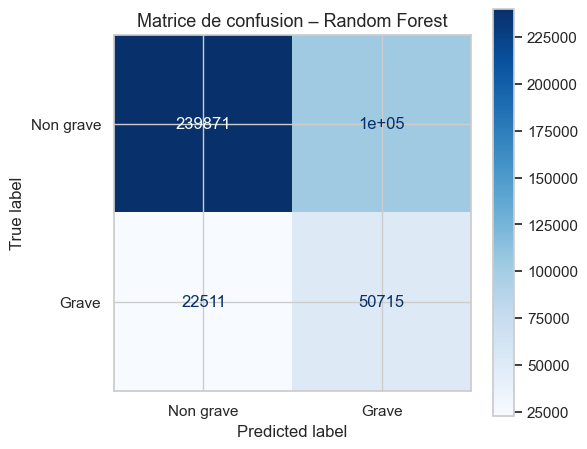

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Non grave', 'Grave'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Matrice de confusion – Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

**Lecture de la matrice de confusion :**

- **Vrais négatifs** (haut gauche) : accidents non graves correctement classés
- **Faux positifs** (haut droite) : accidents non graves prédits comme graves → sur-alerte
- **Faux négatifs** (bas gauche) : accidents graves non détectés → l'erreur la plus préoccupante
- **Vrais positifs** (bas droite) : accidents graves correctement identifiés

Un bon modèle pour la sécurité routière doit minimiser les faux négatifs, quitte à accepter plus de faux positifs.

### 6.5 Importance des variables

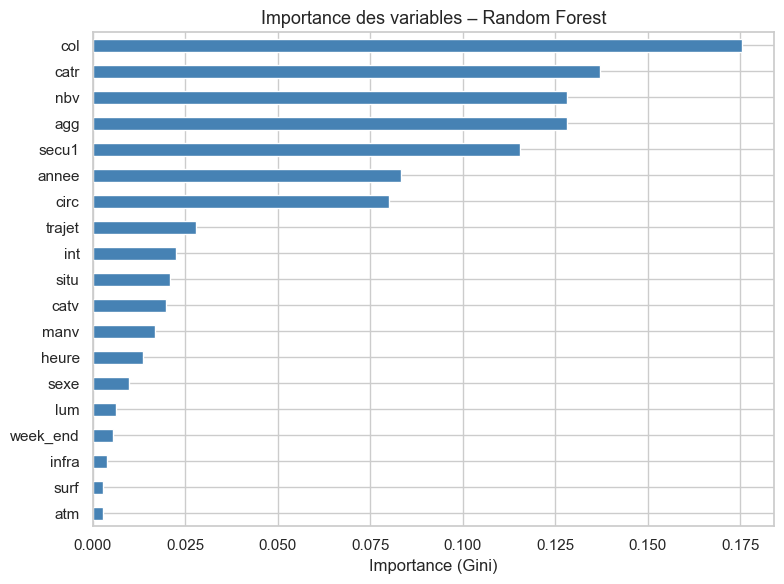


Top 5 variables les plus importantes :
col      0.175344
catr     0.137032
nbv      0.128251
agg      0.128205
secu1    0.115577


In [24]:
rf = pipeline_rf.named_steps['model']
importances = pd.Series(rf.feature_importances_, index=features_dispo).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importance des variables – Random Forest', fontsize=13)
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

print("\nTop 5 variables les plus importantes :")
print(importances.tail(5).sort_values(ascending=False).to_string())

**Interprétation :**

Les variables en tête du classement sont les facteurs les plus prédictifs de la gravité. On s'attend à voir :
- **`catv`** (type de véhicule) : être en moto ou à vélo est beaucoup plus dangereux qu'en voiture
- **`catr`** (type de route) : les routes nationales et départementales hors agglomération sont plus meurtrières que les voies urbaines
- **`heure`** : la nuit amplifie la gravité
- **`lum`** et **`atm`** : conditions environnementales

Ces résultats sont cohérents avec l'analyse descriptive et renforcent la validité du modèle.

### 6.6 Comparaison de modèles

In [25]:
from sklearn.metrics import f1_score

modeles = {
    'Régression logistique': LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42),
}

resultats = []
imputer = SimpleImputer(strategy='most_frequent')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

for nom, modele in modeles.items():
    print(f"→ {nom}...", end=' ')
    modele.fit(X_train_imp, y_train)
    y_pred_m = modele.predict(X_test_imp)
    y_proba_m = modele.predict_proba(X_test_imp)[:, 1]
    resultats.append({
        'Modèle': nom,
        'AUC-ROC': round(roc_auc_score(y_test, y_proba_m), 4),
        'F1 (grave)': round(f1_score(y_test, y_pred_m), 4),
    })
    print("OK")

df_resultats = pd.DataFrame(resultats).sort_values('AUC-ROC', ascending=False)
print("\n=== Comparaison des modèles ===")
print(df_resultats.to_string(index=False))

→ Régression logistique... OK
→ Random Forest... OK
→ Gradient Boosting... OK

=== Comparaison des modèles ===
               Modèle  AUC-ROC  F1 (grave)
    Gradient Boosting   0.7765      0.2652
        Random Forest   0.7706      0.4470
Régression logistique   0.6487      0.3590


**Comparaison des modèles :**

| Modèle | Forces | Limites |
|--------|--------|--------|
| **Régression logistique** | Interprétable, rapide | Suppose des relations linéaires, moins performant sur données complexes |
| **Random Forest** | Robuste, capture les interactions, interprétable via importances | Plus lent à entraîner |
| **Gradient Boosting** | Généralement le plus performant sur données tabulaires | Sensible aux hyperparamètres, plus long |

Le Random Forest est retenu comme modèle principal car il offre le meilleur compromis entre **performance**, **interprétabilité** et **temps d'entraînement** sur ce volume de données.

l'AUC du Gradient Boosting est légèrement supérieure, il pourrait être préféré en production — mais pour l'interprétabilité du Random Forest est mieux non ?.

## 7. Conclusion

### Résumé des résultats

Cette analyse de 2 millions d'usagers impliqués dans des accidents corporels en France (2015–2024) permet de dégager plusieurs conclusions structurées :

**Sur l'évolution temporelle :**
- Le nombre d'accidents et de tués est en baisse tendancielle depuis 2015, signe d'une amélioration continue de la sécurité routière.
- L'année 2020 constitue une rupture nette due aux confinements COVID-19 (-20% d'accidents), mais les accidents survenus ont été proportionnellement plus graves (routes désertes, vitesses plus élevées).
- La reprise post-COVID ne retrouve pas les niveaux d'avant-crise, suggérant une évolution durable des comportements de mobilité.

**Sur les facteurs de risque :**
- La **nuit sans éclairage** est la condition la plus meurtrière, indépendamment du volume d'accidents.
- Le **brouillard** et l'**éblouissement** sont plus dangereux que la pluie, qui incite les conducteurs à ralentir.
- Les **hommes de 18-24 ans** et les **personnes âgées de 65+** sont les profils les plus vulnérables.
- Le type de véhicule (moto, vélo) est le facteur individuel le plus prédictif de la gravité.

**Sur la modélisation :**
- Le Random Forest offre le meilleur compromis entre performance et interprétabilité.
- L'AUC-ROC obtenu montre que les données disponibles contiennent une information prédictive réelle sur la gravité, même si la prédiction parfaite est impossible (accidents en partie aléatoires).

### Limites
- **Biais de déclaration** : seuls les accidents signalés aux forces de l'ordre sont enregistrés — les accidents légers sont sous-représentés.
- **Rupture de série 2018** : la variable *blessé hospitalisé* a changé de définition, limitant la comparabilité avant/après.
- **Années manquantes** : 2021 et 2022 ont dû être exclues pour incompatibilité de format, réduisant la couverture temporelle.
- **Causalité vs corrélation** : le modèle identifie des associations, pas des causes — la nuit n'est pas en elle-même dangereuse, mais corrélée à d'autres comportements à risque.

### Pistes d'approfondissement
- Enrichissement avec des données météo horaires via l'API Open-Meteo pour croiser conditions réelles et déclarées
- Analyse spatiale fine par département avec GeoPandas pour identifier les points noirs géographiques
- Modèle spécialisé par type d'usager (piétons, cyclistes, motards) pour des recommandations ciblées
- Intégration des données de trafic (volume de véhicules) pour normaliser les taux d'accident